In [3]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [4]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    download = True
)

test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor(),
    download = True
)

In [5]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [7]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [8]:
test_data.data.shape

torch.Size([10000, 28, 28])

In [9]:
train_data.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [10]:
test_data.targets

tensor([7, 2, 1,  ..., 4, 5, 6])

In [11]:
from torch.utils.data import DataLoader

loaders = {
    'train': DataLoader(
        train_data,
        batch_size=100,
        shuffle=True,
        num_workers=1
    ),
    'test': DataLoader(
        test_data,
        batch_size=100,
        shuffle=True,
        num_workers=1
    )
}

In [12]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)

        self.conv2_drop = nn.Dropout2d()

        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)

        return F.softmax(x)

In [13]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss()

def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 20 == 0:
            print(f'Train epoch: {epoch} [{batch_idx * len(data)}/{len(loaders["train"].dataset)} ({100. * batch_idx / len(loaders["train"]):.0f}%)]\t{loss.item():.9f}')

def test():
    model.eval()

    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target  in loaders ['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(loaders['test'].dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy {correct}/{len(loaders["test"].dataset)} ({100. * correct / len(loaders["test"].dataset):.0f}%)\n')

In [14]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Compiled CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "not available")

PyTorch: 2.11.0+cu128
CUDA available: True
Compiled CUDA version: 12.8
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [15]:
for epoch in range(1, 11):
    train(epoch)
    test()

C:\Users\meow\AppData\Local\Temp\ipykernel_19140\1389710915.py:26: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


Train epoch: 1 [0/60000 (0%)]	2.304029465
Train epoch: 1 [2000/60000 (3%)]	2.287933111
Train epoch: 1 [4000/60000 (7%)]	2.234458685
Train epoch: 1 [6000/60000 (10%)]	2.048078299
Train epoch: 1 [8000/60000 (13%)]	1.927936435
Train epoch: 1 [10000/60000 (17%)]	1.869956017
Train epoch: 1 [12000/60000 (20%)]	1.773301601
Train epoch: 1 [14000/60000 (23%)]	1.731042743
Train epoch: 1 [16000/60000 (27%)]	1.735773206
Train epoch: 1 [18000/60000 (30%)]	1.758893728
Train epoch: 1 [20000/60000 (33%)]	1.702217579
Train epoch: 1 [22000/60000 (37%)]	1.660166740
Train epoch: 1 [24000/60000 (40%)]	1.699189782
Train epoch: 1 [26000/60000 (43%)]	1.696088910
Train epoch: 1 [28000/60000 (47%)]	1.633887172
Train epoch: 1 [30000/60000 (50%)]	1.655552387
Train epoch: 1 [32000/60000 (53%)]	1.620685697
Train epoch: 1 [34000/60000 (57%)]	1.646854877
Train epoch: 1 [36000/60000 (60%)]	1.695688367
Train epoch: 1 [38000/60000 (63%)]	1.635732770
Train epoch: 1 [40000/60000 (67%)]	1.577910185
Train epoch: 1 [42000/60

Prediction: 7


C:\Users\meow\AppData\Local\Temp\ipykernel_19140\1389710915.py:26: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


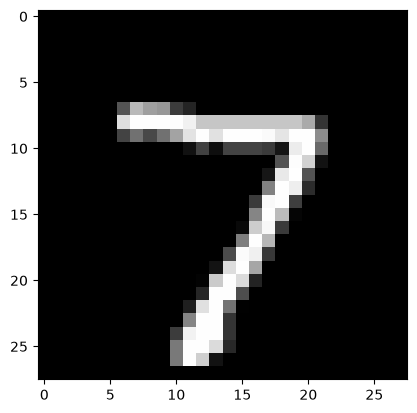

In [25]:
import matplotlib.pyplot as plt

model.eval()

data, target = test_data[0]

data = data.unsqueeze(0).to(device)

output = model(data)

prediction = output.argmax(dim=1, keepdim=True).item()

print(f'Prediction: {prediction}')

image = data.squeeze(0).squeeze(0).cpu().numpy()

plt.imshow(image, cmap='gray')
plt.show()